# Статистика, DS-поток
## Марафон-домашка SM.4, практическая часть

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Выполненную работу нужно отправить телеграм-боту. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания получат штраф.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.

**Баллы за задание:**

* Задача 1 &mdash;  20 баллов
* Задача 2 &mdash;  70 баллов
* Задача 3 &mdash;  150 баллов

**Важность задач:**

* *высокая:* задача 1,2;
* *средне-высокая:* задача 3.

Степень важности задач не связана с количеством баллов и определяется только на основе оценки полезности задачи с точки зрения усвоения текущего и дальнейшего материала. Например, если вы что-то не успеваете, рекомендуется в первую очередь выполнять более важные задачи.


In [ ]:
# Bot check

# HW_ID: ds_sm4
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [229]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(font_scale=1.5, palette=['#7570b3','#e7298a','#66a61e','#1b9e77','#e6ab02','#d95f02'])

from tqdm.notebook import tqdm

______
### Задача 1.
Компания выпустила $n$ серверов новой модели с увеличенным сроком службы. До начала продаж компания должна провести эксперимент по оценке среднего срока службы серверов. Известно, что сервера могут сломаться в любой момент независимо от того, сколько времени уже проработали. Таким образом, распределение времени работы сервера до поломки обладает свойством отсутствия памяти. Как вы знаете, таким свойством среди непрерывных распределений обладает только экспоненциальное распределение.

Компания начала проводить эксперимент, но сервера получились настолько хорошими, что многие еще не сломались, а бизнес уже требует запускать их продажи. Тем самым усложняется задача для аналитиков, которым приходит "обрезанная" выборка.

Рассмотрим задачу более формально. Пусть $X = (X_1, \ldots, X_n)$ &mdash; выборка из экспоненциального распределения с параметром $\theta$ с плотностью $p_\theta(x) = \theta e^{-\theta x}I\{x \geq 0\}$. \
При этом наблюдается выборка $Y = (Y_1, \ldots, Y_n)$, где, $Y_i$ определены следующим образом:
$$
\begin{equation}
  Y_i=\begin{cases}
    X_i, & \text{если $X_i \leq c$}.\\
    c, & \text{если $X_i > c$}.
  \end{cases}
\end{equation}
$$
Иначе говоря, $Y_i = \min(X_i, c)$, где $c$ &mdash; некоторая константа.
Выборка является смесью непрерывного и дискретного распределения, поэтому функция правдоподобия не определена. Вам предлагается реализовать и сравнить три подхода к оценке неизвестного параметра:



**1.** Рассмотреть подвыборку, состоящую из $Y_i < c$, и найти для нее ОМП. Учтите, что необходимо использовать условное распределение $Y_i$ при условии $Y_i < c$.

**Решение:**

In [246]:
n = 10000
theta = 3.0
c = 2.0
x = sps.expon(scale=1/theta).rvs(size=n)
y = np.where(x <= c, x, c)

mask = y < c
y_1 = y[mask]

см. влож.

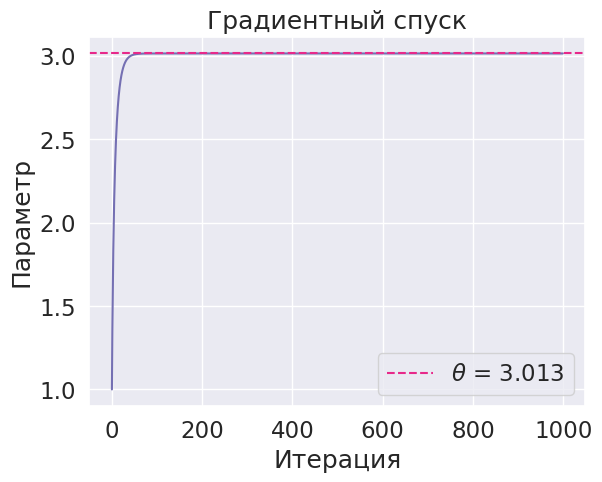

In [247]:
def grad_log_likeltyhood(c, y, t):
    k = len(y)
    return k / t - k * (c * np.exp(-t * c)) / (1 - np.exp(- t * c)) - np.sum(y)
    
m = 1000
theta = np.ones(m)
theta_grid = np.arange(0, m)
eta = 0.0001
for i in theta_grid[1:]:
    theta[i] = theta[i - 1] + eta * grad_log_likeltyhood(c, y_1, theta[i - 1])

plt.plot(theta_grid, theta)
plt.title('Градиентный спуск')
plt.xlabel('Итерация')
plt.ylabel('Параметр')
plt.axhline(y=theta[600:].mean(), linestyle='--', color='#e7298a', label=rf'$\theta$ = {theta[600:].mean():.3f}')
plt.legend()
plt.show()

**2.** Найти оценку, используя метод моментов для всей выборки $Y$.


см. влож.

**Решение:**

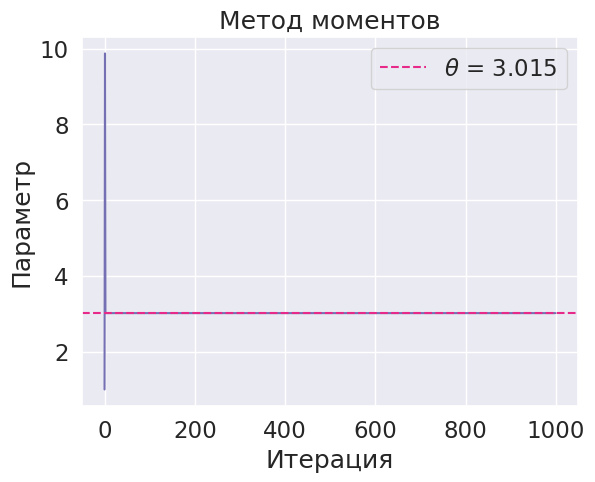

In [248]:
def f(t):
    return 1 - np.exp(-t * c) - t * np.mean(y)

def der_f(t):
    return c * np.exp(- t * c) - np.mean(y)

m = 1000
theta = np.ones(m)
theta_grid = np.arange(0, m)
for i in theta_grid[1:]:
    theta[i] = theta[i - 1] - f(theta[i - 1]) / der_f(theta[i - 1]) 


plt.plot(theta_grid, theta)
plt.title('Метод моментов')
plt.xlabel('Итерация')
plt.ylabel('Параметр')
plt.axhline(y=theta[60:].mean(), linestyle='--', color='#e7298a', label=rf'$\theta$ = {theta[600:].mean():.3f}')
plt.legend()
plt.show()

Попрошу гпт сгенерировать зависиомсть от c

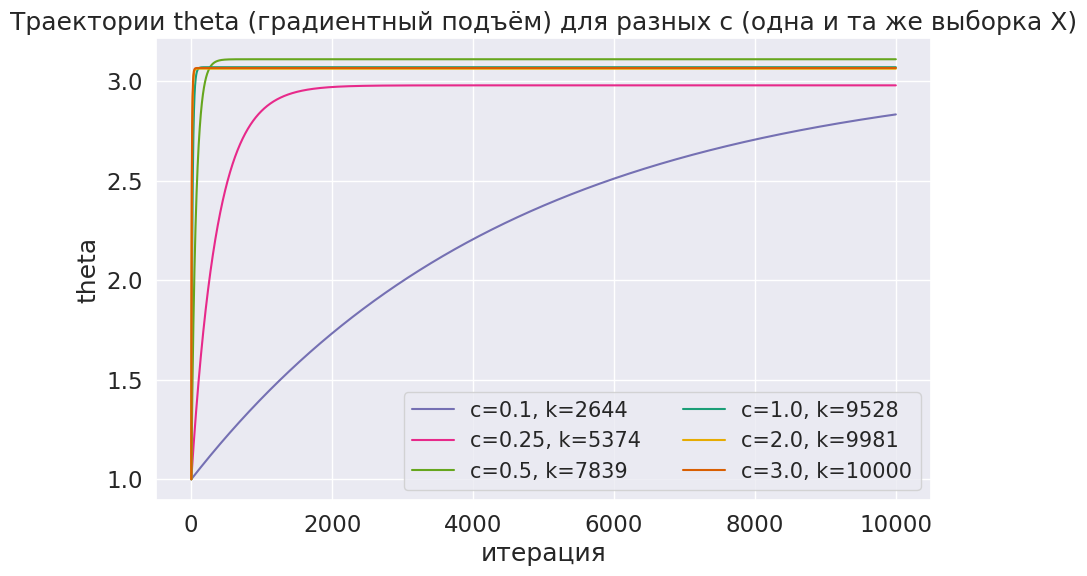

c	k	final_theta	mean_tail(600:)	true_theta
0.1	2644	2.832923	2.297985	3.0
0.25	5374	2.978959	2.964118	3.0
0.5	7839	3.110064	3.110062	3.0
1.0	9528	3.070010	3.070010	3.0
2.0	9981	3.062781	3.062781	3.0
3.0	10000	3.066200	3.066200	3.0


In [162]:
# Повторный запуск: проверка зависимости оценки (градиентный подъём по исходной логике пользователя) от c.
np.random.seed(42)

# параметры
n = 10000
theta_true = 3.0
m = 10000
eta = 0.0001
theta_init = 1.0

# сгенерируем X
x = sps.expon(scale=1/theta_true).rvs(size=n)

c_list = [0.1, 0.25, 0.5, 1.0, 2.0, 3.0]
results = {}
plt.figure(figsize=(10,6))

for c in c_list:
    y = np.where(x <= c, x, c)
    mask = y < c
    y_1 = y[mask]
    
    theta = np.ones(m) * theta_init
    for i in range(1, m):
        theta[i] = theta[i - 1] + eta * ( len(y_1) / theta[i-1] 
                                          - len(y_1) * (c * np.exp(-theta[i-1] * c)) / (1 - np.exp(- theta[i-1] * c)) 
                                          - np.sum(y_1) )
        if theta[i] <= 0:
            theta[i] = 1e-12
    
    final_est = theta[-1]
    mean_tail = theta[600:].mean()
    results[c] = {"final": final_est, "mean_tail": mean_tail, "k": len(y_1), "theta_traj": theta.copy()}
    
    plt.plot(theta, label=f'c={c}, k={len(y_1)}')

plt.title('Траектории theta (градиентный подъём) для разных c (одна и та же выборка X)')
plt.xlabel('итерация')
plt.ylabel('theta')
plt.legend(fontsize='small', ncol=2)
plt.grid(True)
plt.show()

print("c\tk\tfinal_theta\tmean_tail(600:)\ttrue_theta")
for c in c_list:
    r = results[c]
    print(f"{c}\t{r['k']}\t{r['final']:.6f}\t{r['mean_tail']:.6f}\t{theta_true}")


Попрошу гпт повторить экспермиенты

**3.** Найти ОМП по дискретизованной выборке $Y$, выполнив следующие действия.

а) Разбить полуинтервал $[0, c)$ на $k$ бинов (множеств) вида $[a_i, a_{i+1})$, где $0=a_0<a_1<...<a_k=c$. В качестве границ бинов возьмите целые числа.
    
б) Определить $Z_i$ как номер бина, в который попадает $Y_i$, считая при этом множество $\{c\}$ как $(k+1)$-й бин. Вам может помочь функция [`np.digitize`](https://numpy.org/doc/stable/reference/generated/numpy.digitize.html).
    
в) Найти вероятности $p_j(\theta) = \mathsf{P}_\theta(Z_1 = j)$, которые определяют распределение $Z_i$, являющееся дискретным.
    
г) Найти ОМП по выборке $Z_1, ..., Z_n$, используя ее распределение.

Рассмотрите $c = 10$, а в качестве истинного значения параметра возьмите $\theta = 0.15$. Обратите внимание на параметризацию в [`scipy.stats.expon`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.expon.html).
Получить точный ответ в виде формулы у вас скорее всего не получится, воспользуйтесь численными методами.

Насколько точным получается оценка в зависимости от подхода и размера выборки?

см. влож.

**Решение:**

In [250]:
n = 10000
theta = 0.15
c = 10
x = sps.expon(scale=1/theta).rvs(size=n)
y = np.where(x <= c, x, c)

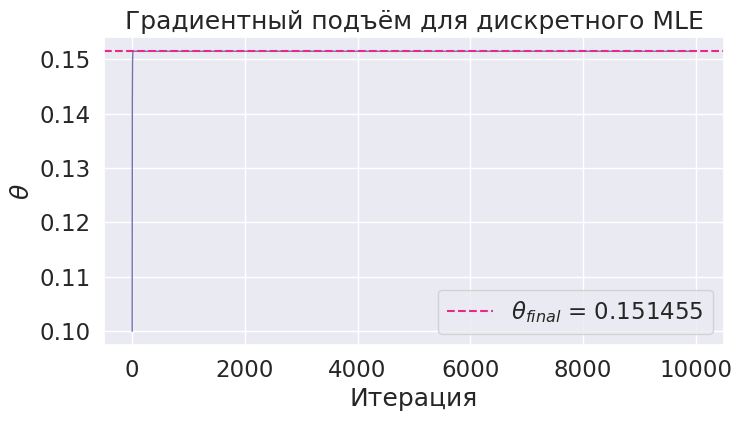

In [253]:
k = 30
a = np.linspace(0, c, k + 1)
z = np.digitize(y, a)

counts = np.bincount(z, minlength=k + 2)[1: k+2]  

def grad_log_likeltyhood(theta, counts, a, c):
    k = len(a) - 1
    exp_vals = np.exp(-theta * a)
    grad = 0.0
    for j in range(1, k+1):
        den = exp_vals[j-1] - exp_vals[j]   
        num = a[j] * exp_vals[j] - a[j-1] * exp_vals[j-1]
        grad += counts[j-1] * (num / den)
    grad += counts[-1] * (-c)
    return grad

m = 10000
theta_seq = np.ones(m)
theta_grid = np.arange(m)
eta = 0.000001
theta_seq[0] = 0.1

for i in theta_grid[1:]:
    t_prev = theta_seq[i-1]
    g = grad_log_likeltyhood(t_prev, counts, a, c)
    theta_seq[i] = t_prev + eta * g

plt.figure(figsize=(8,4))
plt.plot(theta_grid, theta_seq, lw=1)
plt.title('Градиентный подъём для дискретного MLE')
plt.xlabel('Итерация')
plt.ylabel(r'$\theta$')
plt.axhline(y=theta_seq[-1], linestyle='--', color='#e7298a',
            label=rf'$\theta_{{final}}$ = {theta_seq[-1]:.6f}')
plt.legend()
plt.grid(True)
plt.show()


Попрошу гпт построить гистограммы

  0%|          | 0/1000 [00:00<?, ?it/s]

MLE (непрерывный): mean=2.8322, std=0.0741
Метод моментов:     mean=3.0025, std=0.0942
MLE (биновый):     mean=3.0023, std=0.0943


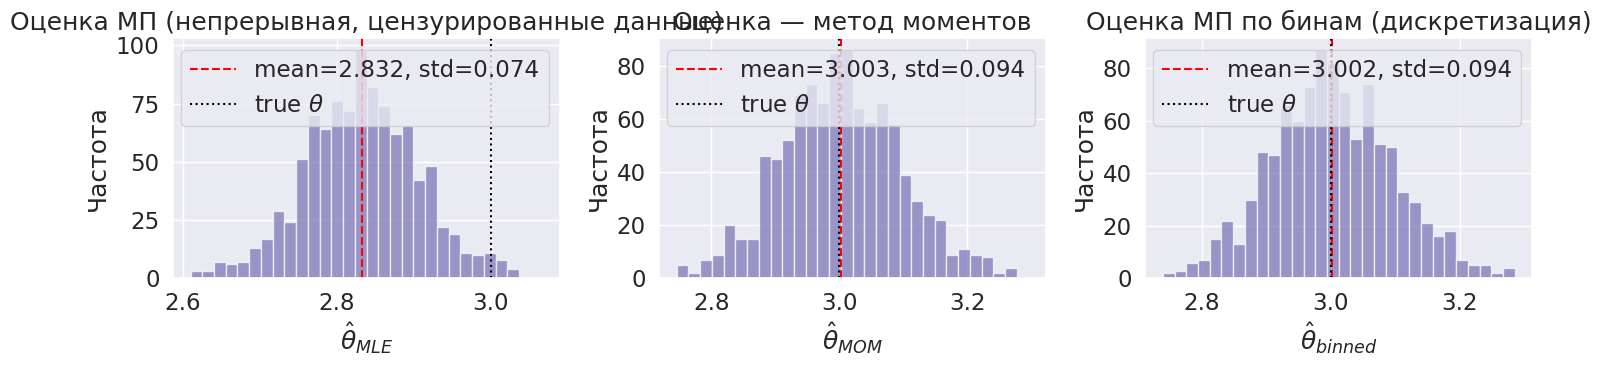

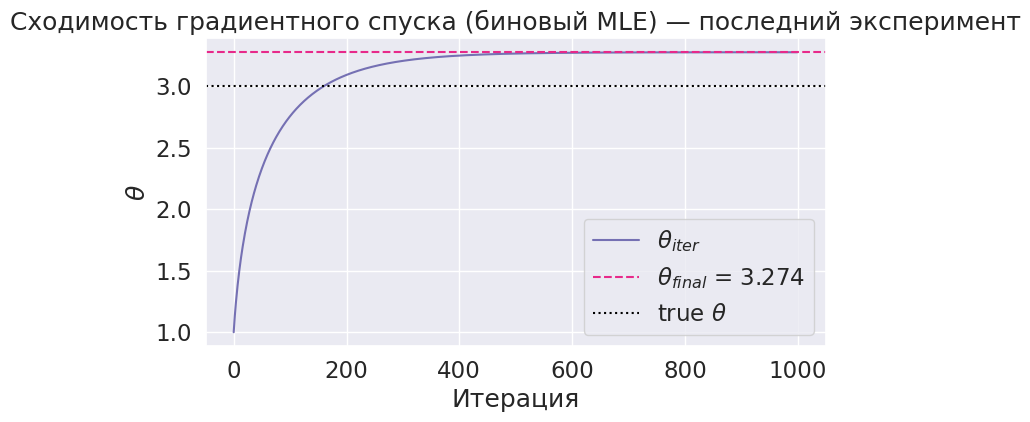

In [254]:
# параметры истинного распределения
n = 1000
theta_true = 3.0
c = 2.0

Nexp = 1000  # число повторений эксперимента

# функции для МП и моментов (оригинальные)
def grad_log_likeltyhood_cont(c, y, t):
    k = len(y)
    # градиент лог-правдоподобия для непрерывно цензурированных наблюдений (усечённое экспоненциальное)
    return k / t - k * (c * np.exp(-t * c)) / (1 - np.exp(-t * c)) - np.sum(y)

def f_mom(t, c, y):
    return 1 - np.exp(-t * c) - t * np.mean(y)

def der_f_mom(t, c, y):
    return c * np.exp(-t * c) - np.mean(y)

# --- Параметры для бинов
k = 30
# a будет задан внутри цикла (зависит от c), но можно задать шаблон
# функция градиента для бинов
def grad_log_likeltyhood_binned(theta, counts, a, c):
    """
    theta: скаляр
    counts: массив длины k+1, где последние counts[-1] = число наблюдений в бин '>= c' (цензурированные)
    a: массив разбиения длины k+1 (границы бинов: a[0],...,a[k])
    c: цензура (последняя граница)
    """
    exp_vals = np.exp(-theta * a)  # длина k+1
    grad = 0.0
    k_local = len(a) - 1
    # первые k бинoв: P(a[j-1] < X <= a[j]) = exp(-theta*a[j-1]) - exp(-theta*a[j])
    for j in range(1, k_local + 1):
        den = exp_vals[j-1] - exp_vals[j]   # p_j
        # чтобы избежать деления на ноль, добавим eps
        den = den if den != 0 else 1e-12
        num = a[j] * exp_vals[j] - a[j-1] * exp_vals[j-1]
        grad += counts[j-1] * (num / den)
    # последний класс: P(X > c) = exp(-theta * c), лог-градиент = d/dθ log = -c
    grad += counts[-1] * (-c)
    return grad

# хранилища оценок
theta_mle_list = []
theta_mom_list = []
theta_binned_list = []

# дополнительные хранилища для примера сходимости (последний эксперимент)
last_theta_seq_binned = None

# цикл по экспериментам
for exp_i in tqdm(range(Nexp)):
    # сгенерировали данные (истинное экспоненциальное распределение + цензура на c)
    x = sps.expon(scale=1/theta_true).rvs(size=n)
    y = np.where(x <= c, x, c)
    mask = y < c
    y_1 = y[mask]  # ненецензурированные наблюдения (для непрерывного МП)

    # --- Метод МП (градиентный спуск) для непрерывного цензурированного правдоподобия
    m = 200
    theta_seq = np.ones(m)
    eta = 0.0001
    for i in range(1, m):
        theta_seq[i] = theta_seq[i - 1] + eta * grad_log_likeltyhood_cont(c, y_1, theta_seq[i - 1])
        # ограничим, чтобы theta оставался положительным
        if theta_seq[i] <= 0:
            theta_seq[i] = 1e-8
    theta_mle_list.append(theta_seq[-1])

    # --- Метод моментов (Ньютон–Рафсон) на исходных (не дискретизированных) y
    theta_seq_mom = np.ones(m)
    for i in range(1, m):
        denom = der_f_mom(theta_seq_mom[i - 1], c, y)
        # защита от деления на ноль
        if np.abs(denom) < 1e-12:
            denom = 1e-12
        theta_seq_mom[i] = theta_seq_mom[i - 1] - f_mom(theta_seq_mom[i - 1], c, y) / denom
        if theta_seq_mom[i] <= 0:
            theta_seq_mom[i] = 1e-8
    theta_mom_list.append(theta_seq_mom[-1])

    # --- Аналогично: дискретизация (бины) + градиентный спуск для бинного правдоподобия
    a = np.linspace(0, c, k + 1)   # границы бинов: a[0]=0, ..., a[k]=c
    z = np.digitize(y, a)          # индексы 1..k+1 (k+1 - значения > a[k-1] включительно)
    # Считаем bincount: хотим k первых интервалов (a[j-1], a[j]] и последний = цензура (==c)
    # digitize возвращает i такой, что a[i-1] < x <= a[i]; для x==c вернёт индекс k+1
    counts = np.bincount(z, minlength=k + 2)[1: k+2]  # длина k+1
    # counts[0] соответствует бин (a0,a1], ..., counts[k-1] -> (a_{k-1}, a_k], counts[k] -> > a_k (=c)
    # запускаем градиентный спуск
    m_b = 1000
    theta_seq_b = np.ones(m_b) * 1.0  # стартовое приближение
    eta_b = 1e-4
    for i in range(1, m_b):
        g = grad_log_likeltyhood_binned(theta_seq_b[i-1], counts, a, c)
        theta_seq_b[i] = theta_seq_b[i-1] + eta_b * g
        if theta_seq_b[i] <= 0:
            theta_seq_b[i] = 1e-8
    theta_binned_list.append(theta_seq_b[-1])

    # сохраним последовательность для последнего эксперимента, чтобы показать график сходимости
    if exp_i == Nexp - 1:
        last_theta_seq_binned = theta_seq_b.copy()

# --- Статистика
mean_mle, std_mle = np.mean(theta_mle_list), np.std(theta_mle_list)
mean_mom, std_mom = np.mean(theta_mom_list), np.std(theta_mom_list)
mean_bin, std_bin = np.mean(theta_binned_list), np.std(theta_binned_list)

print("MLE (непрерывный): mean={:.4f}, std={:.4f}".format(mean_mle, std_mle))
print("Метод моментов:     mean={:.4f}, std={:.4f}".format(mean_mom, std_mom))
print("MLE (биновый):     mean={:.4f}, std={:.4f}".format(mean_bin, std_bin))

# --- Гистограммы для трёх оценок
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(theta_mle_list, bins=30, alpha=0.7)
plt.axvline(mean_mle, color='r', linestyle='--', label=f"mean={mean_mle:.3f}, std={std_mle:.3f}")
plt.axvline(theta_true, color='k', linestyle=':', label=r"true $\theta$")
plt.title('Оценка МП (непрерывная, цензурированные данные)')
plt.xlabel(r'$\hat{\theta}_{MLE}$')
plt.ylabel('Частота')
plt.legend()

plt.subplot(1, 3, 2)
plt.hist(theta_mom_list, bins=30, alpha=0.7)
plt.axvline(mean_mom, color='r', linestyle='--', label=f"mean={mean_mom:.3f}, std={std_mom:.3f}")
plt.axvline(theta_true, color='k', linestyle=':', label=r"true $\theta$")
plt.title('Оценка — метод моментов')
plt.xlabel(r'$\hat{\theta}_{MOM}$')
plt.ylabel('Частота')
plt.legend()

plt.subplot(1, 3, 3)
plt.hist(theta_binned_list, bins=30, alpha=0.7)
plt.axvline(mean_bin, color='r', linestyle='--', label=f"mean={mean_bin:.3f}, std={std_bin:.3f}")
plt.axvline(theta_true, color='k', linestyle=':', label=r"true $\theta$")
plt.title('Оценка МП по бинам (дискретизация)')
plt.xlabel(r'$\hat{\theta}_{binned}$')
plt.ylabel('Частота')
plt.legend()

plt.tight_layout()
plt.show()

# --- График сходимости градиентного спуска для бинов (последний эксперимент)
if last_theta_seq_binned is not None:
    it = np.arange(len(last_theta_seq_binned))
    plt.figure(figsize=(8,4))
    plt.plot(it, last_theta_seq_binned, label=r'$\theta_{iter}$')
    plt.title('Сходимость градиентного спуска (биновый MLE) — последний эксперимент')
    plt.xlabel('Итерация')
    plt.ylabel(r'$\theta$')
    plt.axhline(y=last_theta_seq_binned[-1], linestyle='--', color='#e7298a',
                label=rf'$\theta_{{final}}$ = {last_theta_seq_binned[-1]:.3f}')
    plt.axhline(y=theta_true, color='k', linestyle=':', label=r"true $\theta$")
    plt.legend()
    plt.grid(True)
    plt.show()



**Вывод:** Последни два способ дают наилучшие несмещённые оценки. Видим, что по MLE даже для недоминируемых распрделений можно получать численные хорошие оценки. Метод моментов работает в целом так ж хорошо. Первым способ оценка смещённая, видимо из-за того, что часть наблюдений выкинута из рассмотрения

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока